In [1]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

In [2]:
import cv2
import numpy as np
from mtcnn import MTCNN
import matplotlib.pyplot as plt

detector = MTCNN()

# resize proporsional
def resize_keep_ratio(img, max_size=640):
    h, w = img.shape[:2]
    scale = max_size / max(h, w)
    if scale >= 1:
        return img
    new_w = int(w * scale)
    new_h = int(h * scale)
    return cv2.resize(img, (new_w, new_h))

def detect_face_visualize(img):
    """
    Fungsi ini memproses wajah sekaligus menampilkan visualisasi
    setiap tahapan menggunakan matplotlib.
    """
    # 1. Resize dan Konversi BGR -> RGB
    img = resize_keep_ratio(img)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Siapkan figure untuk plot 6 tahapan
    plt.figure(figsize=(15, 10))
    
    # --- PLOT 1: GAMBAR ASLI ---
    plt.subplot(2, 3, 1)
    plt.imshow(rgb)
    plt.title("1. Gambar Asli (RGB)")
    plt.axis('off')

    # detect wajah
    results = detector.detect_faces(rgb)

    # filter confidence
    results = [r for r in results if r['confidence'] >= 0.8]

    if len(results) == 0:
        print("Wajah tidak terdeteksi.")
        return None

    # ambil wajah terbesar
    results = sorted(results, key=lambda x: x['box'][2] * x['box'][3], reverse=True)
    result = results[0]

    x, y, w, h = result['box']
    if w <= 0 or h <= 0:
        return None

    x = max(0, x)
    y = max(0, y)

    # --- PLOT 2: HASIL DETEKSI MTCNN ---
    img_detected = rgb.copy()
    # Gambar kotak bounding box
    cv2.rectangle(img_detected, (x, y), (x+w, y+h), (0, 255, 0), 3)
    
    # Gambar titik landmark (mata, hidung, mulut)
    keypoints = result.get('keypoints', {})
    for key, point in keypoints.items():
        cv2.circle(img_detected, point, 3, (255, 0, 0), -1)
        
    plt.subplot(2, 3, 2)
    plt.imshow(img_detected)
    plt.title("2. Deteksi & Landmark (MTCNN)")
    plt.axis('off')

    # landmark untuk alignment
    try:
        left_eye = keypoints['left_eye']
        right_eye = keypoints['right_eye']
    except:
        return None

    # sudut wajah
    dx = right_eye[0] - left_eye[0]
    dy = right_eye[1] - left_eye[1]
    angle = np.degrees(np.arctan2(dy, dx))

    # titik tengah mata
    center = (int((left_eye[0] + right_eye[0]) / 2), int((left_eye[1] + right_eye[1]) / 2))

    # rotate wajah
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    aligned = cv2.warpAffine(rgb, M, (rgb.shape[1], rgb.shape[0]))

    # --- PLOT 3: FACE ALIGNMENT ---
    plt.subplot(2, 3, 3)
    plt.imshow(aligned)
    plt.title("3. Face Alignment")
    plt.axis('off')

    # padding wajah
    pad = int(min(w, h) * 0.12)
    x1 = max(0, x-pad)
    y1 = max(0, y-pad)
    x2 = min(aligned.shape[1], x+w+pad)
    y2 = min(aligned.shape[0], y+h+pad)

    # crop wajah
    face_cropped = aligned[y1:y2, x1:x2]
    if face_cropped.size == 0:
        return None

    # --- PLOT 4: CROPPING WAJAH ---
    plt.subplot(2, 3, 4)
    plt.imshow(face_cropped)
    plt.title("4. Cropping Wajah")
    plt.axis('off')

    # CLAHE enhancement untuk memperbaiki kontras
    lab = cv2.cvtColor(face_cropped, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    lab = cv2.merge((l,a,b))
    face_enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # --- PLOT 5: CLAHE ENHANCEMENT ---
    plt.subplot(2, 3, 5)
    plt.imshow(face_enhanced)
    plt.title("5. Perbaikan Kontras (CLAHE)")
    plt.axis('off')

    # resize final
    face_final = cv2.resize(face_enhanced, (128,128), interpolation=cv2.INTER_AREA)

    # --- PLOT 6: RESIZE FINAL ---
    plt.subplot(2, 3, 6)
    plt.imshow(face_final)
    plt.title("6. Resize Final (128x128)")
    plt.axis('off')

    plt.tight_layout()
    plt.show() # Ini akan memunculkan gambar ke layar

    face_final_float = face_final.astype("float32")
    return face_final_float


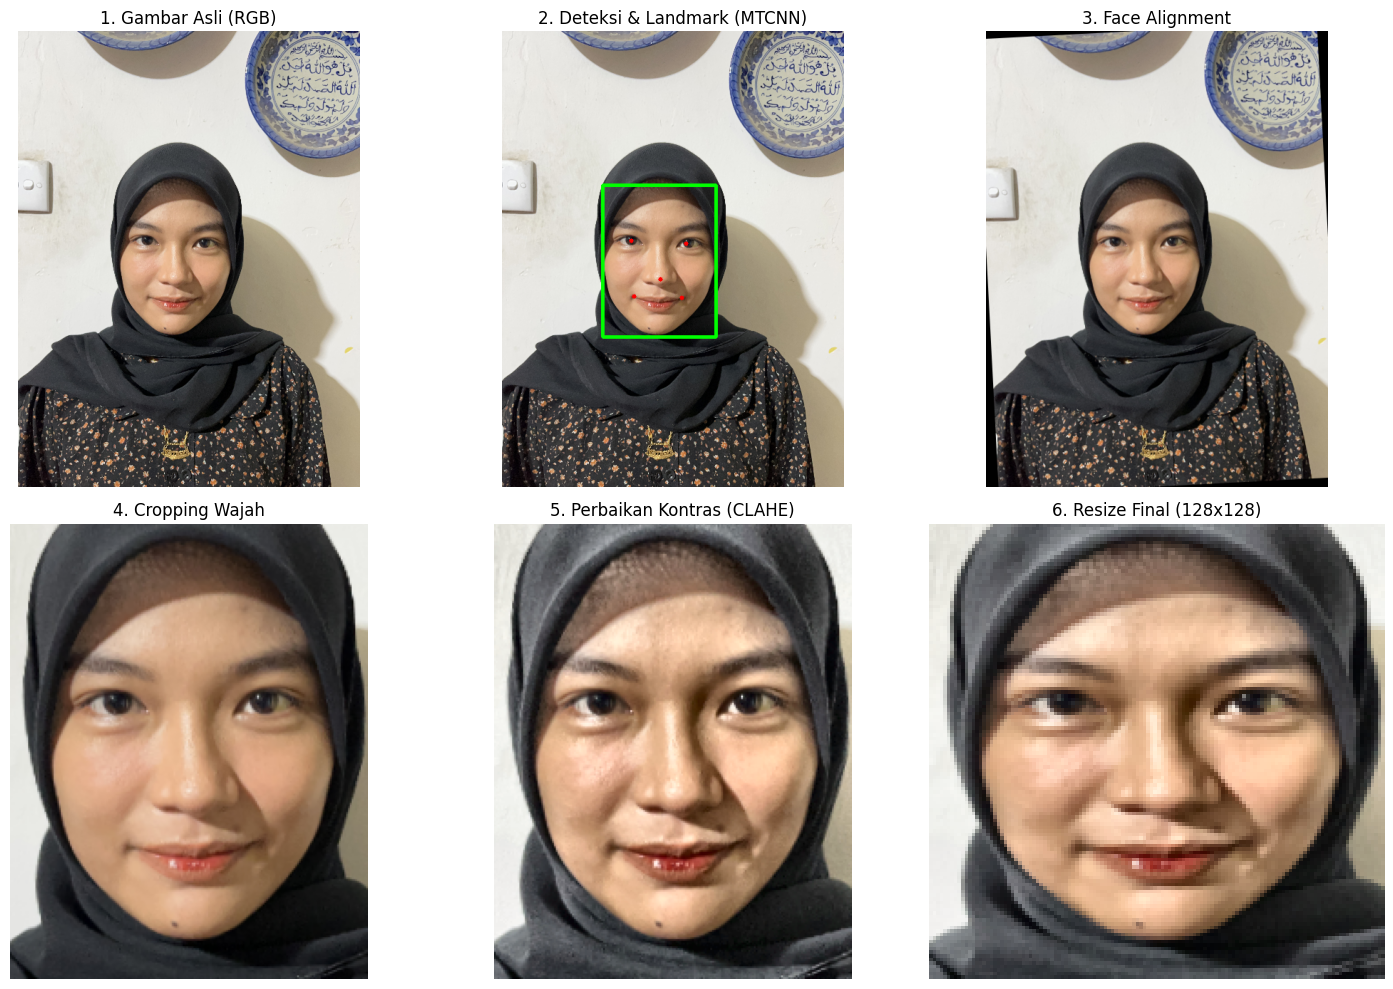

In [4]:
# Ganti path ini dengan salah satu path foto wajah dari dataset Anda
contoh_path_gambar = "Dataset/Dataset_wajah/Natasya Babulrhaiyan/IMG_4083.JPG" 

gambar = cv2.imread(contoh_path_gambar)

if gambar is not None:
    # Memanggil fungsi yang akan menampilkan langkah-langkahnya
    hasil = detect_face_visualize(gambar)
else:
    print("Gambar tidak ditemukan, periksa kembali path gambar Anda.")


In [ ]:
# FACE DETECTION, LANDMARK, FACE ALIGNMENT DAN PREPROCESSING WAJAH

import cv2
import numpy as np
from mtcnn import MTCNN

detector = MTCNN()

# resize proporsional
def resize_keep_ratio(img, max_size=640):

    h, w = img.shape[:2]

    scale = max_size / max(h, w)

    if scale >= 1:
        return img

    new_w = int(w * scale)
    new_h = int(h * scale)

    return cv2.resize(
        img,
        (new_w, new_h)
    )

def detect_face(img):

    # resize proporsional
    img = resize_keep_ratio(img)

    # BGR -> RGB
    rgb = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    # detect wajah
    results = detector.detect_faces(rgb)

    # filter confidence
    results = [
        r for r in results
        if r['confidence'] >= 0.8
    ]

    if len(results) == 0:
        return None

    # ambil wajah terbesar
    results = sorted(
        results,
        key=lambda x:
        x['box'][2] * x['box'][3],
        reverse=True
    )

    result = results[0]

    x, y, w, h = result['box']
    
    if w <= 0 or h <= 0:
        return None

    x = max(0, x)
    y = max(0, y)

    # landmark
    try:

        keypoints = result['keypoints']

        left_eye = keypoints['left_eye']
        right_eye = keypoints['right_eye']

    except:
        return None

    # sudut wajah
    dx = right_eye[0] - left_eye[0]
    dy = right_eye[1] - left_eye[1]

    angle = np.degrees(
        np.arctan2(dy, dx)
    )

    # titik tengah mata
    center = (
        int((left_eye[0] + right_eye[0]) / 2),
        int((left_eye[1] + right_eye[1]) / 2)
    )

    # rotate wajah
    M = cv2.getRotationMatrix2D(
        center,
        angle,
        1.0
    )

    aligned = cv2.warpAffine(
        rgb,
        M,
        (rgb.shape[1], rgb.shape[0])
    )

    # padding wajah
    pad = int(min(w, h) * 0.12)

    x1 = max(0, x-pad)
    y1 = max(0, y-pad)

    x2 = min(aligned.shape[1], x+w+pad)
    y2 = min(aligned.shape[0], y+h+pad)

    # crop wajah
    face = aligned[y1:y2, x1:x2]

    if face.size == 0:
        return None

    # CLAHE enhancement untuk memperbaiki kontras
    lab = cv2.cvtColor(
        face,
        cv2.COLOR_RGB2LAB
    )

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    l = clahe.apply(l)

    lab = cv2.merge((l,a,b))

    face = cv2.cvtColor(
        lab,
        cv2.COLOR_LAB2RGB
    )

    # resize final
    face = cv2.resize(
        face,
        (128,128),
        interpolation=cv2.INTER_AREA
    )

    face = face.astype("float32")

    return face


In [3]:
def print_progress(val, val_len, folder, bar_size=20):
    progr = "#"*round((val)*bar_size/val_len) + " "*round((val_len - (val))*bar_size/val_len)
    if val == 0:
        print("", end = "\n")
    else:
        print("[%s] (%d samples)\t label : %s \t\t" % (progr, val+1, folder), end="\r")

In [4]:
# LOAD DATASET

import gc
import os
import cv2
import random
import numpy as np

dataset_folder = "Dataset/Dataset_wajah"

names = []
images = []

skipped = 0

print("[INFO] Loading dataset...")

for folder in os.listdir(dataset_folder):

    folder_path = os.path.join(
        dataset_folder,
        folder
    )

    if not os.path.isdir(folder_path):
        continue
    files = os.listdir(folder_path)
    random.shuffle(files)
    used = 0

    for i, name in enumerate(files):

        if not name.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            continue
        img_path = os.path.join(
            folder_path,
            name
        )
        img = cv2.imread(img_path)
        if img is None:
            skipped += 1
            continue

        try:

            # face detection + alignment
            img = detect_face(img)

        except Exception as e:

            print(f"[ERROR] {name}")
            skipped += 1
            continue

        if img is not None:

            images.append(img)

            names.append(folder)

            used += 1

            print_progress(
                i,
                len(files),
                folder
            )

        else:
            skipped += 1

        # bersihkan RAM berkala
        if i % 50 == 0:
            gc.collect()

    print(f"\n[OK] {folder}: {used} images")

# convert ke numpy
images = np.array(
    images,
    dtype="float32"
)

names = np.array(names)

print("Total images :", len(images))
print("Total labels :", len(names))
print("Skipped      :", skipped)

[INFO] Loading dataset...

[####################] (105 samples)	 label : Faza Humairah 		
[OK] Faza Humairah: 105 images

[####################] (105 samples)	 label : Jabbal Akbar 		
[OK] Jabbal Akbar: 105 images

[####################] (105 samples)	 label : Muhammad Alif 		
[OK] Muhammad Alif: 104 images

[####################] (105 samples)	 label : Muhammad Heikal Fasya 		
[OK] Muhammad Heikal Fasya: 105 images

[####################] (105 samples)	 label : Muhammad Rizki Arta Maulana 		
[OK] Muhammad Rizki Arta Maulana: 105 images

[####################] (105 samples)	 label : Muhammad Zahrul Ath Thariq 		
[OK] Muhammad Zahrul Ath Thariq: 105 images

[####################] (105 samples)	 label : Nabila Balqis 		
[OK] Nabila Balqis: 105 images

[####################] (105 samples)	 label : Natasya Babulrhaiyan 		
[OK] Natasya Babulrhaiyan: 105 images

[####################] (105 samples)	 label : Nur Fadhillah Zulfi 		
[OK] Nur Fadhillah Zulfi: 105 images

[####################] (

In [5]:
print("number of samples :", len(names))

number of samples : 2091


In [ ]:
# ENCODING LABEL & CATEGORICALIZATION
# Mengubah label nama menjadi numerik dan one-hot encoding untuk CNN

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

import pickle
import os

# folder model
os.makedirs("model", exist_ok=True)

LABEL_PATH = "Label_encoder_face.pickle"

# LABEL ENCODER
le = LabelEncoder()
# encoding label -> angka
y = le.fit_transform(names)
# nama class
labels = le.classes_
# total class
num_classes = len(labels)
# one-hot encoding
y_cat = to_categorical(y)

# SAVE LABEL ENCODER
with open(LABEL_PATH, "wb") as f:
    pickle.dump(le, f)

print("[INFO] Label encoder berhasil disimpan.")
print("[INFO] Total class:", num_classes)
print("[INFO] Classes:")
print(labels)

[INFO] Label encoder berhasil disimpan.
[INFO] Total class: 20
[INFO] Classes:
['Faza Humairah' 'Jabbal Akbar' 'Muhammad Alif' 'Muhammad Heikal Fasya'
 'Muhammad Rizki Arta Maulana' 'Muhammad Zahrul Ath Thariq'
 'Nabila Balqis' 'Natasya Babulrhaiyan' 'Nur Fadhillah Zulfi'
 'Putri Al Violy' 'Rahmat Isma Hidayat' 'Riski Maulani'
 'Salesya Al Fatila' 'Suci Wildani Rizka' 'Syariqul Husni' 'Syifaurrahman'
 'Tasya Anisa' 'Urfi Shanda' 'Vivi Jumilia Hikmah' 'Zuyyin Zafirah']


In [7]:
# SPLIT DATASET
# Membagi dataset menjadi data training dan data testing

from sklearn.model_selection import train_test_split

# CONVERT TO NUMPY

X = np.array(
    images,
    dtype=np.float32
)

y = np.array(y_cat)

# SPLIT DATASET
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# normalisasi validation/test
x_test = x_test.astype("float32") / 255.0

print("x_train shape :", x_train.shape)
print("y_train shape :", y_train.shape)

print("x_test shape  :", x_test.shape)
print("y_test shape  :", y_test.shape)

x_train shape : (1672, 128, 128, 3)
y_train shape : (1672, 20)
x_test shape  : (419, 128, 128, 3)
y_test shape  : (419, 20)


In [8]:
# ==========================================
# IMAGE DATA GENERATOR  (STRONG AUGMENTATION)
# CNN from scratch + data kecil = WAJIB augmentasi agresif
# supaya model tahan terhadap variasi kamera realtime
# (rotasi, geser, cahaya, blur, noise, oklusi, kontras).
# ==========================================
from tensorflow.keras.preprocessing.image import ImageDataGenerator


def custom_augmentation(img):
    """Augmentasi tambahan: blur, noise, random erasing, contrast jitter.
    Input/Output: float32 dengan rentang 0..255 di awal, dinormalisasi /255
    di akhir agar sama dengan x_test (cell SPLIT DATASET).
    """
    img = img.astype("float32")

    # GAUSSIAN BLUR -> simulasi fokus kamera / gerakan kepala
    if np.random.random() < 0.35:
        k = int(np.random.choice([3, 5]))
        img = cv2.GaussianBlur(img, (k, k), 0)

    # GAUSSIAN NOISE -> simulasi noise sensor / cahaya rendah
    if np.random.random() < 0.35:
        sigma = np.random.uniform(5.0, 15.0)
        img = img + np.random.normal(0.0, sigma, img.shape)

    # RANDOM ERASING -> simulasi oklusi (rambut, tangan, masker)
    if np.random.random() < 0.30:
        h, w = img.shape[:2]
        eh = np.random.randint(h // 8, h // 3)
        ew = np.random.randint(w // 8, w // 3)
        ex = np.random.randint(0, max(1, w - ew))
        ey = np.random.randint(0, max(1, h - eh))
        img[ey:ey + eh, ex:ex + ew] = np.random.uniform(
            0, 255, (eh, ew, 3)
        ).astype("float32")

    # CONTRAST JITTER -> simulasi auto-exposure kamera
    if np.random.random() < 0.30:
        alpha = np.random.uniform(0.7, 1.3)
        mean = img.mean(axis=(0, 1), keepdims=True)
        img = (img - mean) * alpha + mean

    # CLIP + NORMALISASI FINAL (samakan skala dgn x_test = /255)
    img = np.clip(img, 0, 255)
    img = img / 255.0
    return img.astype("float32")


# Augmentasi geometrik & cahaya jauh lebih lebar dari versi awal
# (rotasi 5 -> 15, shift 0.03 -> 0.10, zoom 0.05 -> 0.15, brightness wider)
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    shear_range=8,
    brightness_range=[0.65, 1.35],
    horizontal_flip=True,
    fill_mode='nearest',
    preprocessing_function=custom_augmentation,
    dtype='float32'
)

print("[INFO] ImageDataGenerator (STRONG AUG) siap.")


# ==========================================
# MIXUP GENERATOR
# Mixup = mencampur 2 sampel (x1, y1) & (x2, y2) menjadi
#   x_mix = lam*x1 + (1-lam)*x2
#   y_mix = lam*y1 + (1-lam)*y2
# Sangat efektif utk dataset kecil + CNN from scratch karena:
#   - melahirkan ratusan ribu "sampel sintetis" baru
#   - mencegah overfit ke ciri khas tiap sampel
#   - membuat decision boundary lebih halus
# Dipakai sebagai pembungkus datagen.flow di training.
# ==========================================
def mixup_generator(base_datagen, x, y, batch_size=32, alpha=0.2):
    gen = base_datagen.flow(x, y, batch_size=batch_size, shuffle=True)
    while True:
        x1, y1 = next(gen)
        x2, y2 = next(gen)
        n = min(len(x1), len(x2))
        x1, y1 = x1[:n], y1[:n]
        x2, y2 = x2[:n], y2[:n]

        # lam berdistribusi Beta(alpha, alpha), bias ke arah sampel utama
        lam = np.random.beta(alpha, alpha)
        lam = max(lam, 1.0 - lam)

        x_mix = lam * x1 + (1.0 - lam) * x2
        y_mix = lam * y1 + (1.0 - lam) * y2
        yield x_mix.astype("float32"), y_mix.astype("float32")


print("[INFO] mixup_generator siap.")

[INFO] ImageDataGenerator (STRONG AUG) siap.
[INFO] mixup_generator siap.


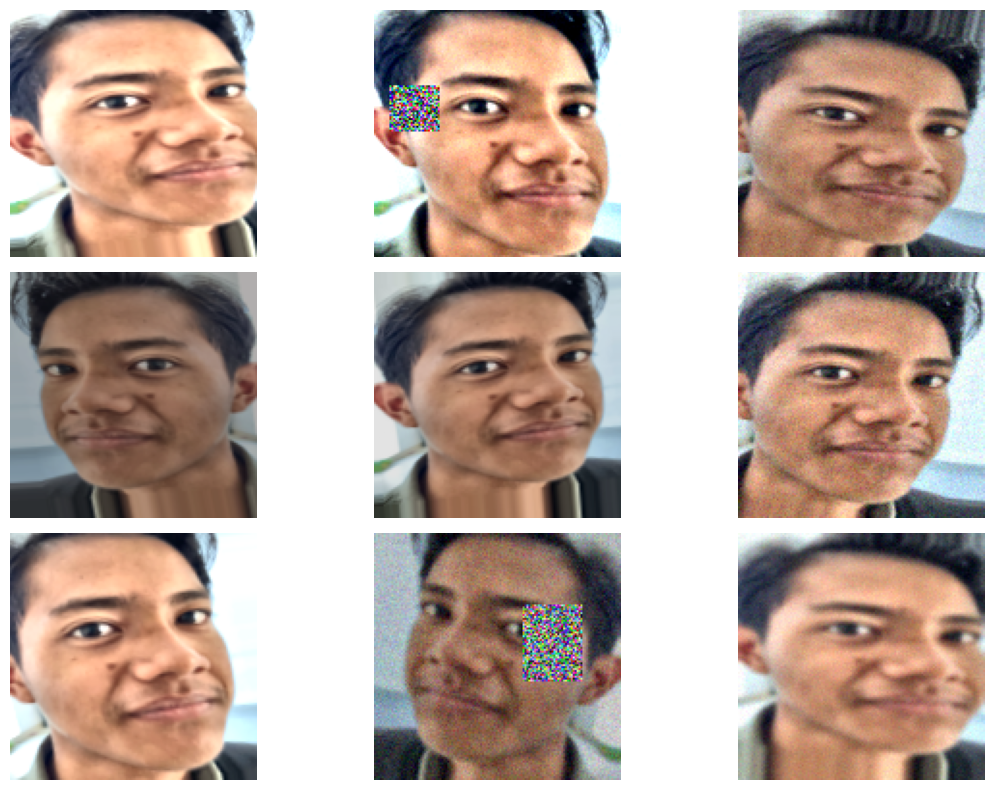

In [9]:
# VISUALISASI HASIL AUGMENTASI

import matplotlib.pyplot as plt
import numpy as np

# ambil 1 gambar sample
img_test = x_train[0]

# ubah shape jadi batch
img_test = np.expand_dims(
    img_test,
    axis=0
)

# generate augmentasi
aug_iter = datagen.flow(
    img_test,
    batch_size=1
)

plt.figure(figsize=(12,8))
for i in range(9):

    # ambil hasil augmentasi
    batch = next(aug_iter)
    aug_img = batch[0]
    plt.subplot(3,3,i+1)
    plt.imshow(aug_img)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [10]:
# Menghitung jumlah data pada setiap label di dataset

unique, counts = np.unique(names, return_counts = True)
for label, total in zip(unique, counts):
    
    print(f"{label:<20} : {total} images")

print("Total class :", len(unique))
print("Total image :", np.sum(counts))

Faza Humairah        : 105 images
Jabbal Akbar         : 105 images
Muhammad Alif        : 104 images
Muhammad Heikal Fasya : 105 images
Muhammad Rizki Arta Maulana : 105 images
Muhammad Zahrul Ath Thariq : 105 images
Nabila Balqis        : 105 images
Natasya Babulrhaiyan : 105 images
Nur Fadhillah Zulfi  : 105 images
Putri Al Violy       : 103 images
Rahmat Isma Hidayat  : 105 images
Riski Maulani        : 102 images
Salesya Al Fatila    : 103 images
Suci Wildani Rizka   : 105 images
Syariqul Husni       : 105 images
Syifaurrahman        : 104 images
Tasya Anisa          : 105 images
Urfi Shanda          : 105 images
Vivi Jumilia Hikmah  : 105 images
Zuyyin Zafirah       : 105 images
Total class : 20
Total image : 2091


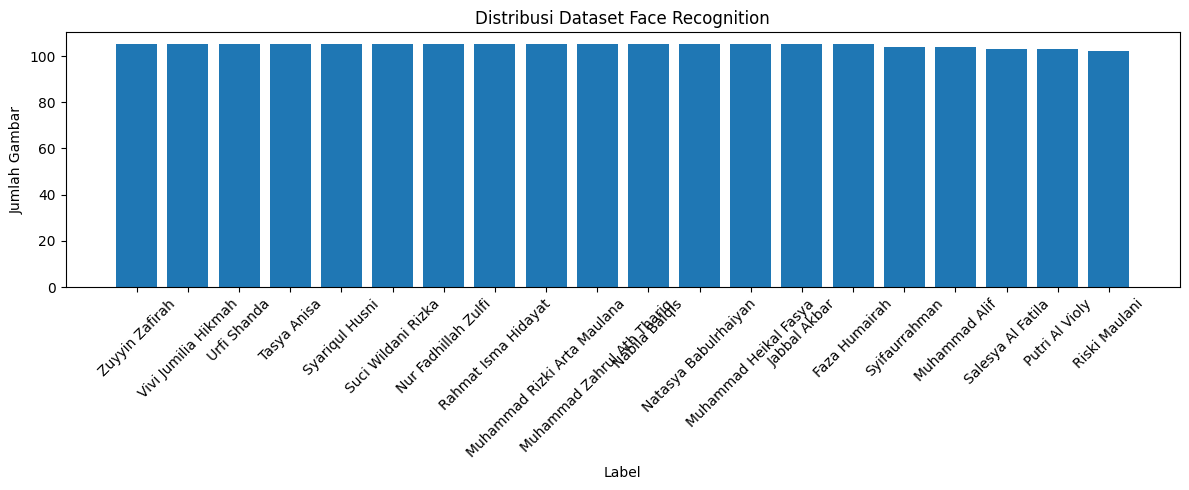

Total class : 20
Total image : 2091


In [11]:
# BALANCING DATA
# Visualisasi distribusi dataset

import matplotlib.pyplot as plt
import numpy as np

# hitung jumlah data
unique, counts = np.unique(
    names,
    return_counts=True
)

# sorting terbesar -> terkecil
sorted_idx = np.argsort(counts)[::-1]

unique = unique[sorted_idx]
counts = counts[sorted_idx]

plt.figure(figsize=(12,5))
plt.bar(unique, counts)
plt.xticks(rotation=45)
plt.xlabel("Label")
plt.ylabel("Jumlah Gambar")
plt.title("Distribusi Dataset Face Recognition")
plt.tight_layout()
plt.show()

print("Total class :", len(unique))
print("Total image :", np.sum(counts))

In [12]:
# Menampilkan jumlah kelas dan nama seluruh kelas/label pada dataset

print(f"Number of classes : {len(labels)}")
print("\nClass Labels :")

for i, label in enumerate(labels):
    print(f"{i} : {label}")

Number of classes : 20

Class Labels :
0 : Faza Humairah
1 : Jabbal Akbar
2 : Muhammad Alif
3 : Muhammad Heikal Fasya
4 : Muhammad Rizki Arta Maulana
5 : Muhammad Zahrul Ath Thariq
6 : Nabila Balqis
7 : Natasya Babulrhaiyan
8 : Nur Fadhillah Zulfi
9 : Putri Al Violy
10 : Rahmat Isma Hidayat
11 : Riski Maulani
12 : Salesya Al Fatila
13 : Suci Wildani Rizka
14 : Syariqul Husni
15 : Syifaurrahman
16 : Tasya Anisa
17 : Urfi Shanda
18 : Vivi Jumilia Hikmah
19 : Zuyyin Zafirah


In [13]:
# Menampilkan label numerik hasil encoding nama peserta

print("Label Mapping :")
for i, label in enumerate(labels):
    print(f"{label} -> {i}")

Label Mapping :
Faza Humairah -> 0
Jabbal Akbar -> 1
Muhammad Alif -> 2
Muhammad Heikal Fasya -> 3
Muhammad Rizki Arta Maulana -> 4
Muhammad Zahrul Ath Thariq -> 5
Nabila Balqis -> 6
Natasya Babulrhaiyan -> 7
Nur Fadhillah Zulfi -> 8
Putri Al Violy -> 9
Rahmat Isma Hidayat -> 10
Riski Maulani -> 11
Salesya Al Fatila -> 12
Suci Wildani Rizka -> 13
Syariqul Husni -> 14
Syifaurrahman -> 15
Tasya Anisa -> 16
Urfi Shanda -> 17
Vivi Jumilia Hikmah -> 18
Zuyyin Zafirah -> 19


In [ ]:
import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

# ==========================================
# CNN MODEL ARCHITECTURE  (FROM SCRATCH, deeper + Attention)
# 4 blok konvolusi: 32 -> 64 -> 128 -> 256
#   - Conv -> BN -> ReLU (pola modern, stabil)
#   - SE block (Squeeze-Excitation) = channel attention.
#     Membuat tiap blok belajar BOBOT fitur penting (mis. mata, hidung)
#     dengan biaya parameter sangat kecil. Tetap "from scratch".
#   - SpatialDropout2D di tiap blok
#   - L2 regularizer di tiap Conv2D
# Functional API supaya bisa pakai skip-multiply utk SE.
# Label smoothing diturunkan 0.05 -> 0.02 supaya prediksi tidak
# under-confident di realtime (sebelumnya threshold sering tidak tercapai).
# ==========================================
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    SpatialDropout2D,
    BatchNormalization,
    GlobalAveragePooling2D,
    Activation,
    Reshape,
    Multiply,
)
from tensorflow.keras.regularizers import l2
import tensorflow as tf


def se_block(x, ratio=8):
    """Squeeze-Excitation: belajar bobot per channel (channel attention)."""
    ch = x.shape[-1]
    s = GlobalAveragePooling2D()(x)
    s = Dense(max(ch // ratio, 4), activation="relu",
              kernel_regularizer=l2(1e-4))(s)
    s = Dense(ch, activation="sigmoid",
              kernel_regularizer=l2(1e-4))(s)
    s = Reshape((1, 1, ch))(s)
    return Multiply()([x, s])


def conv_block(x, filters, sp_dropout, name=None):
    """2x (Conv -> BN -> ReLU) + SE + MaxPool + SpatialDropout."""
    x = Conv2D(filters, (3, 3), padding="same",
               kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(filters, (3, 3), padding="same",
               kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = se_block(x, ratio=8)            # <-- channel attention
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = SpatialDropout2D(sp_dropout)(x)
    return x


def cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    x = conv_block(inputs, 32,  0.20)
    x = conv_block(x,      64,  0.25)
    x = conv_block(x,      128, 0.30)
    x = conv_block(x,      256, 0.35)

    # classification head
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(0.5)(x)

    outputs = Dense(len(labels), activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs, name="cnn_se_scratch")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
        metrics=["accuracy"],
    )
    model.summary()
    return model

In [ ]:
# MELIHAT OUTPUT DARI PROSES EKSTRAKSI FITUR CNN (INTERMEDIATE LAYER)
from tensorflow.keras.models import Model

# 1. Kita potong model CNN kita.
# Ambil dari Input awal, sampai layer sebelum layer terakhir (klasifikasi).
# Layer ke -2 biasanya adalah layer Dense/Flatten yang murni berisi 'Fitur Numerik' hasil ekstraksi.
feature_extractor_model = Model(inputs=model.input, outputs=model.layers[-2].output)

# 2. Ambil 1 gambar wajah untuk dites
gambar_uji = x_test[0:1]

# 3. Ekstrak fiturnya
hasil_fitur = feature_extractor_model.predict(gambar_uji)

print('\n=== BENTUK OUTPUT DARI EKSTRAKSI FITUR ===')
print(f'Dimensi/Ukuran matriks fitur: {hasil_fitur.shape}')
print(f'Total ada {hasil_fitur.shape[1]} angka/fitur numerik yang diekstrak dari wajah tersebut.\n')

print('=== CONTOH ANGKA NUMERIK HASIL EKSTRAKSI FITUR ===')
print(hasil_fitur[0][:50]) # Hanya menampilkan 50 angka pertama agar layar tidak penuh
print('... (dan seterusnya sampai selesai)')


In [ ]:
# ==========================================
# TRAINING MODEL CNN  (mixup + cosine LR)
# Strategi gabungan utk CNN from scratch + dataset kecil:
#   - mixup_generator  : data sintetis tak terhingga
#   - CosineDecay      : LR menurun mulus (lebih baik dari ReduceLROnPlateau
#                        ketika dipasangkan dengan mixup)
#   - patience besar   : model dalam butuh waktu konvergen
#   - class_weight     : balancing antar-kelas
# Catatan: dengan mixup, target y BUKAN one-hot murni, sehingga
# `class_weight` di model.fit tidak kompatibel (Keras mensyaratkan
# label kelas integer). Pengganti: importance reweighting via mixup
# sudah cukup. class_weights tetap dihitung utk informasi.
# ==========================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
)
from sklearn.utils.class_weight import compute_class_weight

# ==========================================
# INPUT SHAPE
# ==========================================
input_shape = x_train[0].shape

# ==========================================
# HYPERPARAMETER
# ==========================================
EPOCHS     = 100
BATCH_SIZE = 32
STEPS      = max(1, len(x_train) // BATCH_SIZE)

# ==========================================
# CLASS WEIGHT (informasi)
# ==========================================
y_train_labels = np.argmax(y_train, axis=1)
cw = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels,
)
print("[INFO] class_weights:", {int(i): float(round(w, 3)) for i, w in enumerate(cw)})

# ==========================================
# COSINE LR SCHEDULE
# Turun mulus dari 5e-4 -> ~1e-6 dlm EPOCHS*STEPS langkah.
# ==========================================
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-4,
    decay_steps=EPOCHS * STEPS,
    alpha=1e-6 / 5e-4,   # ratio LR akhir terhadap awal
)

# ==========================================
# CALLBACK
# ==========================================
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1,
)
checkpoint = ModelCheckpoint(
    "face_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1,
)

# ==========================================
# BUILD MODEL  (override optimizer dgn cosine LR)
# ==========================================
model = cnn_model(input_shape)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    metrics=["accuracy"],
)

# ==========================================
# TRAINING MODEL  (pakai mixup_generator)
# ==========================================
train_gen = mixup_generator(
    datagen, x_train, y_train,
    batch_size=BATCH_SIZE, alpha=0.2,
)

history = model.fit(
    train_gen,
    steps_per_epoch=STEPS,
    validation_data=(x_test, y_test),
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint],
    verbose=1,
)

[INFO] class_weights: {0: 0.995, 1: 0.995, 2: 1.007, 3: 0.995, 4: 0.995, 5: 0.995, 6: 0.995, 7: 0.995, 8: 0.995, 9: 1.02, 10: 0.995, 11: 1.02, 12: 1.02, 13: 0.995, 14: 0.995, 15: 1.007, 16: 0.995, 17: 0.995, 18: 0.995, 19: 0.995}


Model: "cnn_se_scratch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ activation_1[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        132 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        160 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 128, 128,  │          0 │ activation_1[0][… │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ multiply[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│ (SpatialDropout2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ spatial_dropout2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ activation_2[0][

 Total params: 1,270,352 (4.85 MB)

 Trainable params: 1,267,920 (4.84 MB)

 Non-trainable params: 2,432 (9.50 KB)

Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.0490 - loss: 3.9013
Epoch 1: val_accuracy improved from None to 0.05012, saving model to best_model.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 170s 3s/step - accuracy: 0.0549 - loss: 3.7450 - val_accuracy: 0.0501 - val_loss: 3.1276
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.0741 - loss: 3.5758
Epoch 2: val_accuracy did not improve from 0.05012
52/52 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.0848 - loss: 3.4642 - val_accuracy: 0.0501 - val_loss: 3.1802
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1119 - loss: 3.2891
Epoch 3: val_accuracy did not improve from 0.05012
52/52 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.1170 - loss: 3.1997 - val_accuracy: 0.0501 - val_loss: 3.3143
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1338 - loss: 3.0519
Epoch 4: val_accuracy improved from 0.05012 to 0.07876, saving model to best_model.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 131s 3s/step

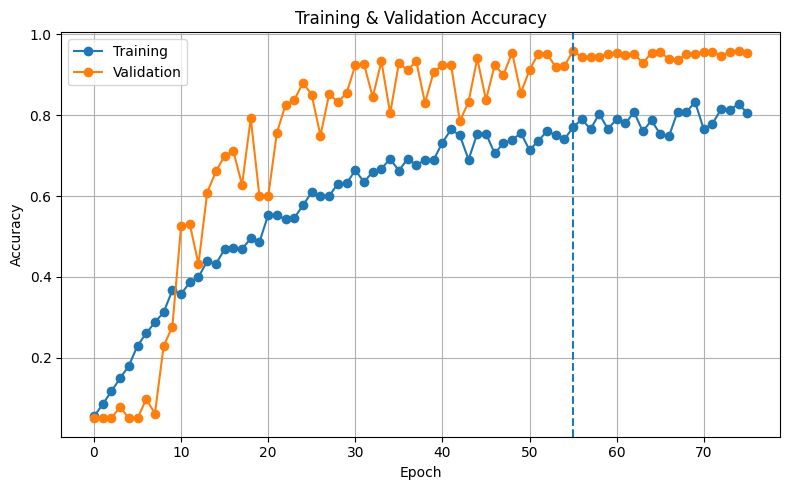


Best Epoch : 56
Best Validation val_accuracy : 0.9594


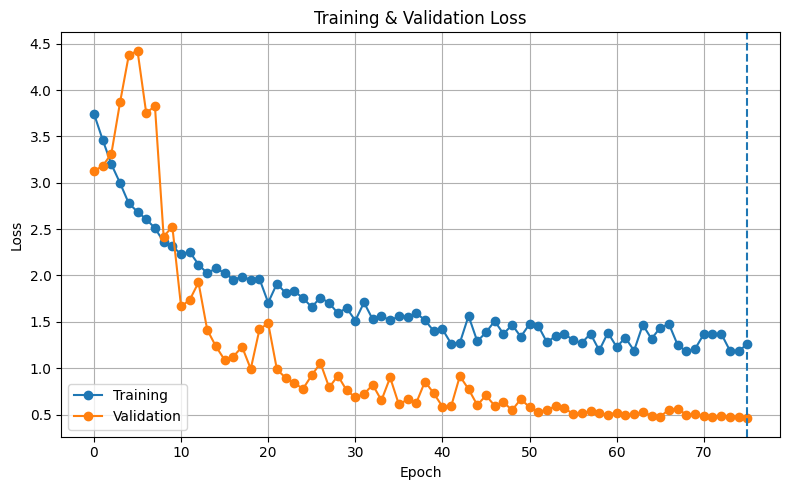


Best Epoch : 76
Best Validation val_loss : 0.4594


In [16]:
# ==========================================
# VISUALISASI HASIL TRAINING CNN
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(history):

    metrics = [
        ['accuracy', 'val_accuracy'],
        ['loss', 'val_loss']
    ]

    titles = [
        'Training & Validation Accuracy',
        'Training & Validation Loss'
    ]

    for i, metric in enumerate(metrics):

        plt.figure(figsize=(8,5))

        # training
        plt.plot(
            history.history[metric[0]],
            marker='o',
            label='Training'
        )

        # validation
        plt.plot(
            history.history[metric[1]],
            marker='o',
            label='Validation'
        )

        # best epoch
        if metric[0] == 'accuracy':

            best_epoch = np.argmax(
                history.history[metric[1]]
            )

            best_value = np.max(
                history.history[metric[1]]
            )

        else:

            best_epoch = np.argmin(
                history.history[metric[1]]
            )

            best_value = np.min(
                history.history[metric[1]]
            )

        plt.axvline(
            best_epoch,
            linestyle='--'
        )

        plt.xlabel('Epoch')

        plt.ylabel(metric[0].capitalize())

        plt.title(titles[i])

        plt.legend(loc='best')

        plt.grid(True)

        plt.tight_layout()

        plt.show()

        # ==================================
        # INFO METRIC
        # ==================================

        print("\n==========================")

        print(f"Best Epoch : {best_epoch+1}")

        print(
            f"Best Validation "
            f"{metric[1]} : "
            f"{best_value:.4f}"
        )

        print("==========================")

# ==========================================
# TAMPILKAN HASIL TRAINING
# ==========================================

evaluate_model(history)

In [ ]:
model.save("face_model.keras")

In [18]:
# Melakukan prediksi pada data testing menggunakan model CNN

# prediksi probabilitas
y_pred = model.predict(
    x_test,
    verbose=0
)

# class hasil prediksi
y_pred_classes = np.argmax(
    y_pred,
    axis=1
)

# class label sebenarnya
y_true = np.argmax(
    y_test,
    axis=1
)

# confidence score
confidence_scores = np.max(
    y_pred,
    axis=1
)

print("[INFO] Prediksi selesai.")

print("Total testing data :", len(y_true))

[INFO] Prediksi selesai.
Total testing data : 419


In [ ]:
# MENAMPILKAN BUKTI OUTPUT NUMERIK DARI CNN 
import numpy as np

gambar_uji = x_test[0:1]
label_asli_index = np.argmax(y_test[0])

hasil_mentah = model.predict(gambar_uji)

print('=== Output Numerik Mentah dari CNN (Probabilitas) ===')
print(hasil_mentah)

index_pemenang = np.argmax(hasil_mentah)
probabilitas_tertinggi = hasil_mentah[0][index_pemenang]

print('\n=== Hasil Analisis ===')
print(f'Index dengan angka terbesar : {index_pemenang}')
print(f'Nilai Peluang (Confidence)  : {probabilitas_tertinggi:.4f} atau {(probabilitas_tertinggi*100):.2f}%')

nama_prediksi = le.inverse_transform([index_pemenang])[0]
nama_asli = le.inverse_transform([label_asli_index])[0]
print(f'\nNama yang ditebak CNN : {nama_prediksi}')
print(f'Nama Asli sebenarnya  : {nama_asli}')


In [19]:
# CONFUSION MATRIX

# ==========================================
# CONFUSION MATRIX
# ==========================================

import itertools
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(

    cm,

    classes,

    normalize=False,

    title='Confusion Matrix',

    cmap=plt.cm.Blues
):

    # ======================================
    # NORMALISASI
    # ======================================

    if normalize:

        cm = cm.astype('float') / cm.sum(
            axis=1
        )[:, np.newaxis]

    # ======================================
    # HITUNG AKURASI
    # ======================================

    accuracy = np.trace(cm) / np.sum(cm)

    # ======================================
    # VISUALISASI
    # ======================================

    plt.figure(figsize=(12,10))

    plt.imshow(
        cm,
        interpolation='nearest',
        cmap=cmap
    )

    plt.title(
        f"{title}\nAccuracy: {accuracy:.4f}"
    )

    plt.colorbar()

    tick_marks = np.arange(len(classes))

    plt.xticks(
        tick_marks,
        classes,
        rotation=90,
        fontsize=8
    )

    plt.yticks(
        tick_marks,
        classes,
        fontsize=8
    )

    # ======================================
    # TEXT MATRIX
    # ======================================

    fmt = '.2f' if normalize else 'd'

    thresh = cm.max() / 2.

    for i, j in itertools.product(
        range(cm.shape[0]),
        range(cm.shape[1])
    ):

        plt.text(

            j,
            i,

            format(cm[i, j], fmt),

            horizontalalignment="center",

            color=(
                "white"
                if cm[i, j] > thresh
                else "black"
            ),

            fontsize=8
        )

    # ======================================
    # LABEL
    # ======================================

    plt.ylabel('True Label')

    plt.xlabel('Predicted Label')

    plt.subplots_adjust(
        bottom=0.25,
        left=0.25
    )

    plt.tight_layout()

    plt.show()

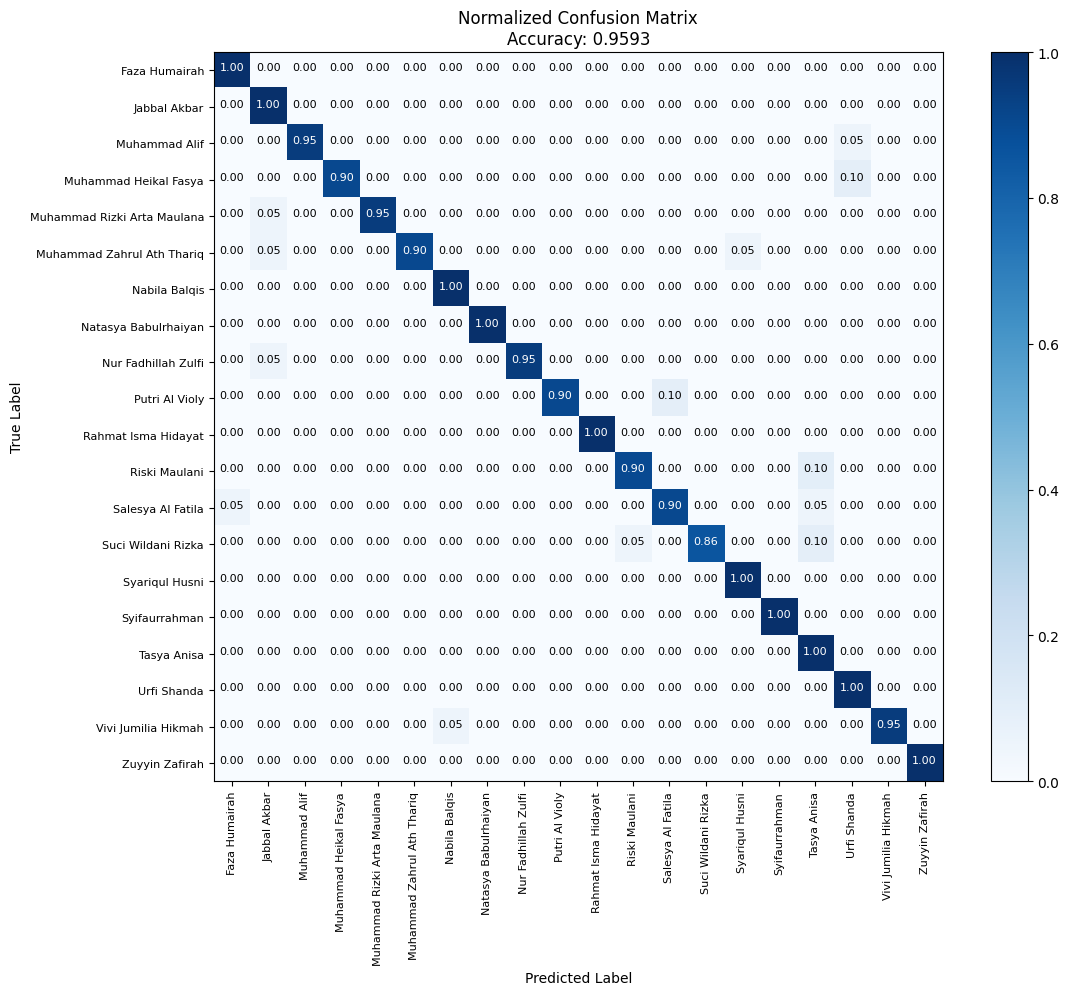


Accuracy : 0.9594


In [20]:
from sklearn.metrics import confusion_matrix
import numpy as np

# hitung confusion matrix
cnf_matrix = confusion_matrix(

    y_true,

    y_pred_classes
)

# menampilkan angka desimal
np.set_printoptions(precision=2)

# visualisasi confusion matrix
plot_confusion_matrix(

    cnf_matrix,

    classes=labels,

    normalize=True,

    title='Normalized Confusion Matrix'
)

accuracy = np.trace(cnf_matrix) / np.sum(cnf_matrix)

print(f"\nAccuracy : {accuracy:.4f}")


In [21]:
# Menampilkan hasil evaluasi klasifikasi model CNN
# CLASSIFICATION REPORT

from sklearn.metrics import (
    classification_report,
    accuracy_score
)

# hitung accuracy
accuracy = accuracy_score(
    y_true,
    y_pred_classes
)

print("\n==========================")
print("HASIL EVALUASI MODEL CNN")
print("==========================")

print(f"Accuracy : {accuracy:.4f}")

print("\nClassification Report:\n")

# classification report
report = classification_report(

    y_true,

    y_pred_classes,

    target_names=labels,

    zero_division=0
)

print(report)

print("==========================")


HASIL EVALUASI MODEL CNN
Accuracy : 0.9594

Classification Report:

                             precision    recall  f1-score   support

              Faza Humairah       0.95      1.00      0.98        21
               Jabbal Akbar       0.88      1.00      0.93        21
              Muhammad Alif       1.00      0.95      0.98        21
      Muhammad Heikal Fasya       1.00      0.90      0.95        21
Muhammad Rizki Arta Maulana       1.00      0.95      0.98        21
 Muhammad Zahrul Ath Thariq       1.00      0.90      0.95        21
              Nabila Balqis       0.95      1.00      0.98        21
       Natasya Babulrhaiyan       1.00      1.00      1.00        21
        Nur Fadhillah Zulfi       1.00      0.95      0.98        21
             Putri Al Violy       1.00      0.90      0.95        21
        Rahmat Isma Hidayat       1.00      1.00      1.00        21
              Riski Maulani       0.95      0.90      0.92        20
          Salesya Al Fatila      

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

accuracy = accuracy_score(y_true, y_pred_classes)

report = classification_report(
    y_true,
    y_pred_classes,
    target_names=labels,
    zero_division=0
)

with open("hasil_evaluasi_cnn.txt", "w", encoding="utf-8") as f:
    f.write("==========================\n")
    f.write("HASIL EVALUASI MODEL CNN\n")
    f.write("==========================\n")
    f.write(f"Accuracy : {accuracy:.4f}\n\n")
    f.write("Classification Report:\n\n")
    f.write(report)
    f.write("\n==========================")

print(report)

In [2]:
# ==========================================
# REALTIME FACE RECOGNITION  (CNN from scratch)
# Konsisten 100% dengan pipeline training:
#   detect_face -> align -> CLAHE -> resize(IMG_SIZE) -> /255
# Tambahan supaya stabil di kamera:
#   - voting nama antar BUFFER_SIZE frame
#   - threshold pakai stable_conf + diff top1-top2
#   - label encoder pakai file yang BENAR (Label_encoder_cnn_new.pickle)
# ==========================================
import cv2
import numpy as np
import pickle
from collections import deque, Counter

from mtcnn import MTCNN
from tensorflow.keras.models import load_model

# ==========================================
# CONFIG  (HARUS SAMA dgn training detect_face)
# ==========================================
IMG_SIZE             = 128
MTCNN_CONF           = 0.90       # ambang deteksi wajah
CONFIDENCE_THRESHOLD = 0.50       # diturunkan: label_smoothing dikurangi
                                  # tapi TTA juga akan menstabilkan conf
DIFF_THRESHOLD       = 0.05       # margin top1-top2 dilonggarkan
BUFFER_SIZE          = 7          # jumlah frame utk voting
USE_TTA              = True       # rata-rata prediksi: original + flip + zoom

# ==========================================
# LOAD MODEL & LABEL ENCODER
# ==========================================
detector = MTCNN()
model    = load_model("best_model.keras")

with open("Label_encoder_face.pickle", "rb") as f:
    le = pickle.load(f)

print(f"[INFO] Model dimuat. {len(le.classes_)} kelas: {list(le.classes_)}")

# ==========================================
# PREPROCESS  (SAMA dgn detect_face di training)
# ==========================================
clahe_op = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def preprocess_face_rt(rgb, box, keypoints):
    x, y, w, h = box
    if w <= 0 or h <= 0:
        return None, None
    x, y = max(0, x), max(0, y)

    left_eye  = keypoints['left_eye']
    right_eye = keypoints['right_eye']

    # alignment by eye angle
    dx = right_eye[0] - left_eye[0]
    dy = right_eye[1] - left_eye[1]
    angle  = np.degrees(np.arctan2(dy, dx))
    center = (int((left_eye[0] + right_eye[0]) / 2),
              int((left_eye[1] + right_eye[1]) / 2))

    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    aligned = cv2.warpAffine(rgb, M, (rgb.shape[1], rgb.shape[0]))

    pad = int(min(w, h) * 0.12)
    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(aligned.shape[1], x + w + pad)
    y2 = min(aligned.shape[0], y + h + pad)
    face = aligned[y1:y2, x1:x2]
    if face.size == 0:
        return None, None

    # CLAHE pada L (LAB)
    lab = cv2.cvtColor(face, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l = clahe_op.apply(l)
    face = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)

    # resize + normalize SAMA dgn x_test (/255)
    face = cv2.resize(face, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    face = face.astype("float32") / 255.0
    return face, (x1, y1, x2, y2)


# ==========================================
# TEST-TIME AUGMENTATION (TTA)
# Bukan utk training, melainkan utk INFERENSI:
# - Buat beberapa versi input wajah (asli, flip horizontal, sedikit zoom-in)
# - Prediksi semua, lalu RATA-RATAKAN softmax
# Efek:
#   * confidence prediksi yang benar -> NAIK (averaging meredam noise)
#   * prediksi yang salah -> turun (tidak konsisten antar versi)
# Tetap CNN from scratch, hanya teknik inferensi.
# ==========================================
def _center_zoom(img01, factor=0.9):
    """Crop tengah -> resize balik ke IMG_SIZE. img01 sudah dlm [0,1]."""
    h, w = img01.shape[:2]
    nh, nw = int(h * factor), int(w * factor)
    y0 = (h - nh) // 2
    x0 = (w - nw) // 2
    crop = img01[y0:y0 + nh, x0:x0 + nw]
    return cv2.resize(crop, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)


def predict_tta(model, face01):
    """face01: HxWx3 float32 [0,1]. Return softmax (1D)."""
    if not USE_TTA:
        return model.predict(face01[None, ...], verbose=0)[0]

    variants = [
        face01,                                  # original
        face01[:, ::-1, :],                      # horizontal flip
        _center_zoom(face01, 0.90),              # zoom-in 10%
    ]
    batch = np.stack(variants, axis=0).astype("float32")
    preds = model.predict(batch, verbose=0)      # (3, n_class)
    return preds.mean(axis=0)


# ==========================================
# REALTIME LOOP
# ==========================================
name_buffer  = deque(maxlen=BUFFER_SIZE)
proba_buffer = deque(maxlen=BUFFER_SIZE)

cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT,  720)

print("[INFO] Tekan 'q' untuk keluar.")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    results = [r for r in detector.detect_faces(rgb)
               if r['confidence'] >= MTCNN_CONF]

    # ambil wajah TERBESAR saja (1 orang per frame)
    results = sorted(results,
                     key=lambda r: r['box'][2] * r['box'][3],
                     reverse=True)

    if results:
        result = results[0]
        try:
            face_in, bbox = preprocess_face_rt(
                rgb, result['box'], result['keypoints']
            )
        except Exception:
            face_in, bbox = None, None

        if face_in is not None and bbox is not None:
            # TTA: rata-rata softmax atas beberapa varian input
            preds     = predict_tta(model, face_in)
            top1_idx  = int(np.argmax(preds))
            top1_conf = float(preds[top1_idx])
            top2_conf = float(np.partition(preds, -2)[-2])
            diff      = top1_conf - top2_conf

            # voting antar frame supaya stabil
            name_buffer.append(le.classes_[top1_idx])
            proba_buffer.append(top1_conf)

            stable_name = Counter(name_buffer).most_common(1)[0][0]
            stable_conf = float(np.mean([
                p for n, p in zip(name_buffer, proba_buffer)
                if n == stable_name
            ]))

            if stable_conf >= CONFIDENCE_THRESHOLD and diff >= DIFF_THRESHOLD:
                label_text = f"{stable_name} ({stable_conf * 100:.1f}%)"
                color = (0, 220, 0)
            else:
                label_text = f"Unknown ({stable_conf * 100:.1f}%)"
                color = (0, 50, 220)

            x1, y1, x2, y2 = bbox
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame, label_text, (x1, max(0, y1 - 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

            # debug top-3 di terminal
            top3 = np.argsort(preds)[::-1][:3]
            info = "  |  ".join(
                f"{le.classes_[i]}: {preds[i] * 100:.1f}%" for i in top3
            )
            print(f"\r[PRED] {info}    ", end="")
    else:
        # tidak ada wajah -> reset buffer biar tidak salah carry-over
        name_buffer.clear()
        proba_buffer.clear()

    # info threshold di pojok
    cv2.putText(
        frame,
        f"Th: {CONFIDENCE_THRESHOLD*100:.0f}%  diff>= {DIFF_THRESHOLD*100:.0f}%",
        (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1
    )

    cv2.imshow("Face Recognition", frame)
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print("\n[INFO] Kamera dimatikan.")

[INFO] Model dimuat. 20 kelas: [np.str_('Faza Humairah'), np.str_('Jabbal Akbar'), np.str_('Muhammad Alif'), np.str_('Muhammad Heikal Fasya'), np.str_('Muhammad Rizki Arta Maulana'), np.str_('Muhammad Zahrul Ath Thariq'), np.str_('Nabila Balqis'), np.str_('Natasya Babulrhaiyan'), np.str_('Nur Fadhillah Zulfi'), np.str_('Putri Al Violy'), np.str_('Rahmat Isma Hidayat'), np.str_('Riski Maulani'), np.str_('Salesya Al Fatila'), np.str_('Suci Wildani Rizka'), np.str_('Syariqul Husni'), np.str_('Syifaurrahman'), np.str_('Tasya Anisa'), np.str_('Urfi Shanda'), np.str_('Vivi Jumilia Hikmah'), np.str_('Zuyyin Zafirah')]
[INFO] Tekan 'q' untuk keluar.
[PRED] Putri Al Violy: 83.8%  |  Zuyyin Zafirah: 5.2%  |  Tasya Anisa: 2.2%       5%    
[INFO] Kamera dimatikan.


In [1]:
# ==========================================
# A. FINE-TUNE dari best_model.keras  +  DATA REALTIME BARU
# ==========================================
# LANGKAH SEBELUM menjalankan cell ini:
#   1) Buka terminal baru di folder project.
#   2) Untuk SETIAP orang, jalankan capture realtime (variasikan pose & cahaya):
#         python capture_realtime.py --name "Nama Orang" --n 30
#      File akan disimpan ke Dataset/Dataset_wajah/<Nama Orang>/realtime_NNN.jpg
#   3) Jalankan ulang cell 3 (LOAD DATASET), 5 (LABEL ENCODER), 6 (SPLIT)
#      supaya foto-foto realtime baru ikut masuk ke x_train / x_test.
#   4) Baru jalankan cell ini.
#
# Cell ini melakukan FINE-TUNE: tidak retrain dari nol, hanya melanjutkan
# pelatihan model terbaik dengan LR jauh lebih kecil, jadi cepat
# (sekitar 20-30 epoch sudah cukup).

from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# muat checkpoint terbaik
print("[INFO] Memuat best_model.keras untuk fine-tune...")
model = load_model("best_model.keras")

# LR fine-tune jauh lebih kecil (1e-4 -> 1e-6 secara cosine)
FT_EPOCHS = 30
FT_STEPS  = max(1, len(x_train) // BATCH_SIZE)

ft_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=FT_EPOCHS * FT_STEPS,
    alpha=1e-6 / 1e-4,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=ft_lr),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    metrics=["accuracy"],
)

# pakai mixup generator yang sama
ft_train_gen = mixup_generator(
    datagen, x_train, y_train, batch_size=BATCH_SIZE, alpha=0.2,
)

ft_callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
    ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

print("[INFO] Mulai fine-tune...")
history_ft = model.fit(
    ft_train_gen,
    steps_per_epoch=FT_STEPS,
    validation_data=(x_test, y_test),
    epochs=FT_EPOCHS,
    callbacks=ft_callbacks,
    verbose=1,
)

print("[INFO] Fine-tune selesai. best_model.keras sudah diperbarui.")

KeyboardInterrupt: 